In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
from pyhdf.SD import SD, SDC
from scipy.interpolate import interp2d
from matplotlib.font_manager import FontProperties
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

mpl.rcParams['font.family'] = ['SimHei'] 
mpl.rcParams['axes.unicode_minus'] = False  


MODIS数据通常在发布之前已经进行了一定程度的预处理，包括几何校正

In [77]:
# 读取文件，用pyhdf读取遥感图像数据
# FILE_NAME = 'Modis/MOD021KM.A2023216.0140.061.2023216131913.hdf'
# FILE_NAME = 'Modis/MOD021KM.A2023167.0105.061.2023167132045.hdf'
FILE_NAME = 'Modis/MYD021KM.A2023182.0450.061.2023182154004.hdf'

DATAFIELD_NAME = 'EV_250_Aggr1km_RefSB'
 
hdf = SD(FILE_NAME, SDC.READ)
 
attrs = hdf.attributes(full=1)
nsa = attrs["Number of Scans"]
number_of_Scans = nsa[0]
 
# 提取近红外波段
data2D = hdf.select(DATAFIELD_NAME)
data = data2D[1,:,:].astype(np.double)
 

# 获取辐射校正所需的数据（辐射校正消除仪器本身的误差）
lat = hdf.select('Latitude')
latitude = lat[:,:]
lon = hdf.select('Longitude')
longitude = lon[:,:]
 
attrs=lat.attributes(full=1)
fna = attrs["frame_numbers"]
frame_numbers = fna[0][0]
lna = attrs["line_numbers"]
line_numbers = lna[0][0]
 
attrs = data2D.attributes(full=1)
lna=attrs["long_name"]
long_name = lna[0]
aoa=attrs["radiance_offsets"]
add_offset = aoa[0][0]
sfa=attrs["radiance_scales"]
scale_factor = sfa[0][0]  
fva=attrs["_FillValue"]
_FillValue = fva[0]
vra=attrs["valid_range"]
valid_min = vra[0][0]        
valid_max = vra[0][1]
ua=attrs["units"]
units = ua[0]
            


HDF4Error: SD: no such file

In [78]:
# 创建插值函数
lon_interp = interp2d(range(longitude.shape[1]), range(longitude.shape[0]), longitude, kind='linear')
lat_interp = interp2d(range(latitude.shape[1]), range(latitude.shape[0]), latitude, kind='linear')

# 生成新的网格
new_x = np.linspace(0, longitude.shape[1] - 1, data.shape[1])
new_y = np.linspace(0, latitude.shape[0] - 1, data.shape[0])

# 插值经纬度数据
longitude = lon_interp(new_x, new_y)
latitude = lat_interp(new_x, new_y)

# 现在 new_longitude 和 new_latitude 应该和 data 具有相同的shape
print(longitude.shape)
print(latitude.shape)

(25, 274)
(25, 274)


C:\Users\14390\AppData\Local\Temp\ipykernel_133332\2734244182.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  lon_interp = interp2d(range(longitude.shape[1]), range(longitude.shape[0]), longitude, kind='linear')
C:\Users\14390\AppData\Local\Temp\ipykernel_133332\2734244182.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code

In [79]:
# 经纬度转换为十进制度
def dms_to_dd(degrees, minutes, direction):
    dd = float(degrees) + float(minutes)/60
    if direction == 'S' or direction == 'W':
        dd *= -1
    return dd

# 转换给定的经纬度范围
lon_min = dms_to_dd(118, 58, 'E')
lon_max = dms_to_dd(125, 32, 'E')
lat_min = dms_to_dd(31, 30, 'N')
lat_max = dms_to_dd(36, 10, 'N')


# 创建掩码来筛选经纬度范围内的数据点
lat_mask = (latitude >= lat_min) & (latitude <= lat_max)
lon_mask = (longitude >= lon_min) & (longitude <= lon_max)
combined_mask = lat_mask & lon_mask


In [80]:
invalid = np.logical_or(data > valid_max,
                        data < valid_min)
invalid = np.logical_or(invalid, data == _FillValue)
data[invalid] = np.nan
data = (data - add_offset) * scale_factor 
data = np.ma.masked_array(data, np.isnan(data))

In [81]:
print(combined_mask.shape)
print(data.shape)

(25, 274)
(25, 274)


In [83]:
# 获取所有为 True 的元素的索引
true_indices = np.where(combined_mask)

# 计算行的最小和最大索引
row_min = np.min(true_indices[0])
row_max = np.max(true_indices[0])

# 计算列的最小和最大索引
col_min = np.min(true_indices[1])
col_max = np.max(true_indices[1])

# 输出结果
print("Row range: ", row_min, row_max)
print("Column range: ", col_min, col_max)

ValueError: zero-size array to reduction operation minimum which has no identity

In [68]:
# 应用掩码到数据
# data = np.ma.masked_where(~combined_mask, data)

data = data[row_min:row_max + 1, col_min:col_max + 1]
latitude = latitude[row_min:row_max + 1, col_min:col_max + 1]
longitude = longitude[row_min:row_max + 1, col_min:col_max + 1]

In [69]:
print(data.shape)
print(latitude.shape)

(25, 274)
(25, 274)


(25, 274)


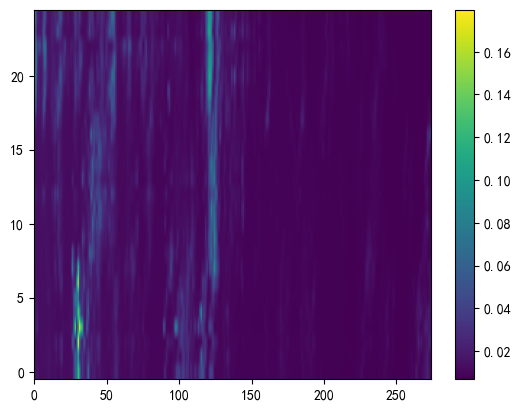

In [70]:
# 假设 data 是一个二维数组
plt.imshow(data[::-1], origin='lower', aspect='auto')
print(data.shape)
# 添加颜色条
plt.colorbar()

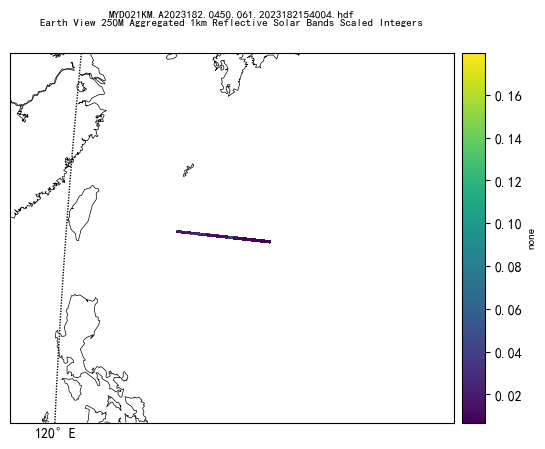

In [71]:
# 获取经纬度中心
lat_m = np.nanmean(latitude)
lon_m = np.nanmean(longitude)        

m = Basemap(projection='laea', resolution='l', lat_ts=65,
            lat_0=lat_m, lon_0=lon_m,
            width=3000000, height=2500000)
m.drawcoastlines(linewidth=0.5)
m.drawparallels(np.arange(50., 91., 10.), labels=[1, 0, 0, 0])
m.drawmeridians(np.arange(-180, 181., 30), labels=[0, 0, 0, 1])
 
m.pcolormesh(longitude, latitude, data, latlon=True)
cb=m.colorbar()
cb.set_label(units, fontsize=8)
 
basename = os.path.basename(FILE_NAME)

plt.title('{0}\n{1}\n{2}\n{3}'.format(basename,
                                      long_name[0:81],
                                      long_name[81:158],
                                      long_name[158:]),
          fontsize=8)
fig = plt.gcf()
pngfile = "Output/{0}.py.png".format(basename)
fig.savefig(pngfile)

In [72]:
# 读取红光波段的数据
red_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS红光波段1的数据字段
red_data = red_band[0,:,:].astype(np.double)
# 读取近红外波段的数据
nir_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS近红外波段2的数据字段
nir_data = nir_band[1,:,:].astype(np.double)

In [73]:
RVI = (nir_data) / (red_data)

In [74]:
RVI = RVI[row_min:row_max + 1, col_min:col_max + 1]

(574, 281)


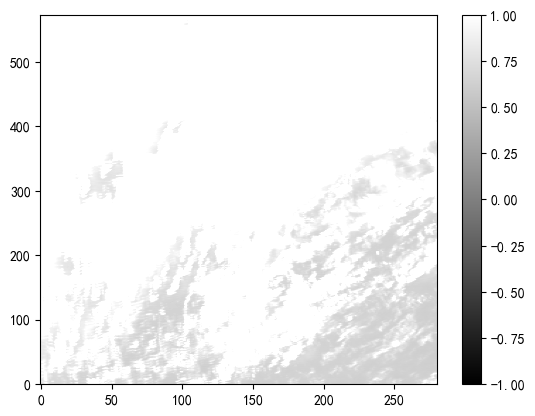

In [75]:
# 假设 data 是一个二维数组
plt.imshow(RVI[::-1], origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
print(RVI.shape)
# 添加颜色条
plt.colorbar()

TypeError: Dimensions of C (574, 281) should be one smaller than X(274) and Y(25) while using shading='flat' see help(pcolormesh)

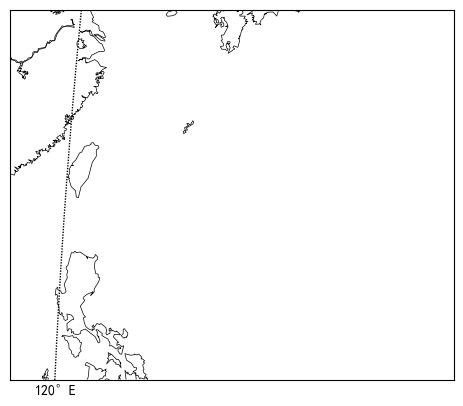

In [76]:
# 获取经纬度中心
lat_m = np.nanmean(latitude)
lon_m = np.nanmean(longitude)        

m = Basemap(projection='laea', resolution='l', lat_ts=65,
            lat_0=lat_m, lon_0=lon_m,
            width=3000000, height=2500000)
m.drawcoastlines(linewidth=0.5)
m.drawparallels(np.arange(50., 91., 10.), labels=[1, 0, 0, 0])
m.drawmeridians(np.arange(-180, 181., 30), labels=[0, 0, 0, 1])
 
# m.pcolormesh(longitude, latitude, RVI, latlon=True)
m.pcolormesh(longitude, latitude, RVI, latlon=True, cmap='RdYlGn', vmin=-1, vmax=1)
cb=m.colorbar()
cb.set_label(units, fontsize=8)
 
basename = os.path.basename(FILE_NAME)

plt.title('{0}\n{1}\n{2}\n{3}'.format(basename,
                                      long_name[0:81],
                                      long_name[81:158],
                                      long_name[158:]),
          fontsize=8)
fig = plt.gcf()
pngfile = "Output/{0}.py.png".format(basename)
fig.savefig(pngfile)

In [53]:
print(RVI,RVI.shape)

[[1.78228827 1.7789573  1.77797142 ... 1.80337838 1.80047211 1.80747195]
 [1.77117952 1.76301848 1.76618487 ... 1.78394007 1.78223877 1.78933301]
 [1.76627337 1.75955373 1.76191637 ... 1.78655921 1.78447395 1.78518692]
 ...
 [0.82878412 0.79643766 0.87123947 ... 0.94964029 1.17385257 1.12888889]
 [0.80559085 0.76872536 0.83770287 ... 1.15759312 0.97504456 0.85657371]
 [0.83706468 0.79139505 0.78720627 ... 1.17323944 1.07667732 0.794926  ]] (574, 281)


In [54]:
RVI_min = RVI.min()
RVI_max = RVI.max()
RVI_normalized = (RVI - RVI_min) / (RVI_max - RVI_min)

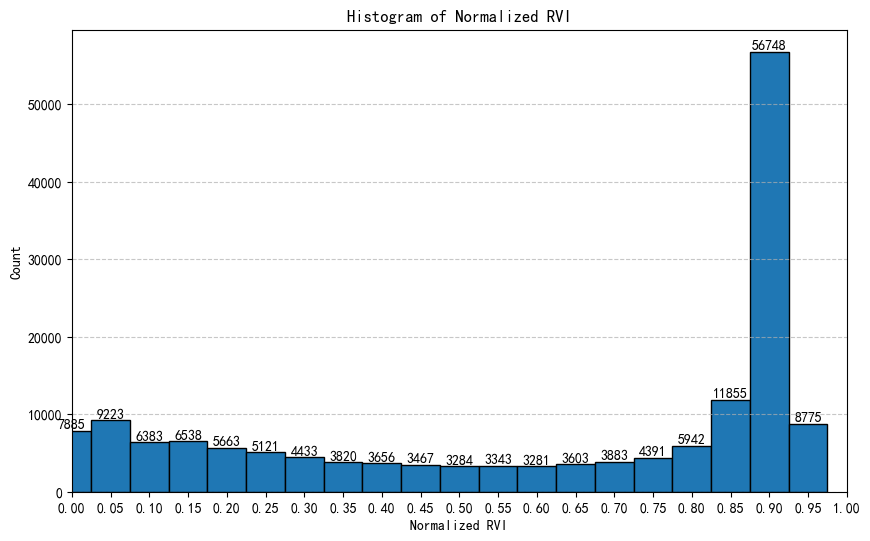

In [55]:
# 计算0-1范围内每0.05间隔的值的数量
bins = np.arange(0, 1.05, 0.05)  # 创建从0到1的边界，每0.05一个区间
hist, bin_edges = np.histogram(RVI_normalized, bins=bins)

# 绘制柱状图
plt.figure(figsize=(10, 6))  # 设置画布大小
bars = plt.bar(bin_edges[:-1], hist, width=0.05, edgecolor='black')  # 绘制柱状图

# 在每个柱子上方添加文本
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.xlim(0, 1)  # 设置x轴范围
plt.xticks(np.arange(0, 1.05, 0.05))  # 设置x轴刻度
plt.xlabel('Normalized RVI')  # 设置x轴标签
plt.ylabel('Count')  # 设置y轴标签
plt.title('Histogram of Normalized RVI')  # 设置标题
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 设置网格线
plt.show()  # 显示图表

In [56]:
print(np.sum(RVI_normalized < 0.11))

18497


In [57]:
print(np.sum(RVI_normalized < 0.12))

19781


设置阈值在0.11时格外明显

In [58]:
# 过滤大部分噪声的清晰图像
RVI_Filtered = (RVI - RVI_min) / (RVI_max - RVI_min)
RVI_Filtered[RVI_Filtered > 0.10] = 1
RVI_Filtered[RVI_Filtered <= 0.10] = 0
RVI_Filtered = RVI_Filtered * -1 +1
RVI_Filtered = RVI_Filtered[::-1]

RVI_Gray = (RVI - RVI_min) / (RVI_max - RVI_min)
RVI_Gray[RVI_Gray > 0.10] = 0
RVI_Gray = RVI_Gray * (RVI_max - RVI_min) + RVI_min
RVI_Gray = RVI_Gray[::-1]


In [59]:
print(np.sum(RVI_Filtered == 1))

17108


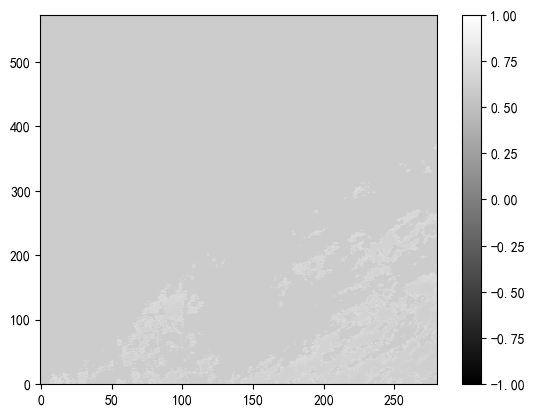

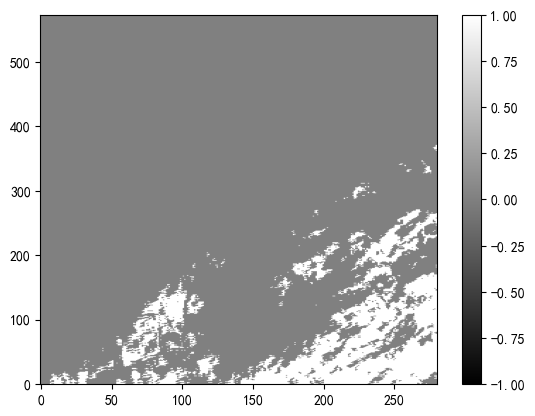

In [60]:
plt.imshow(RVI_Gray, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

plt.figure()
plt.imshow(RVI_Filtered, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

# 聚类提取海藻范围群

In [61]:
# 示例数据，RVI_Filtered是一个二维数组，这里是随机生成的示例。
# 提取值为1的点的坐标
points = np.argwhere(RVI_Filtered == 1)

# 创建DBSCAN对象
dbscan = DBSCAN(eps=3, min_samples=2)

# 拟合数据
dbscan.fit(points)

# 获取聚类标签
labels = dbscan.labels_

# 提取核心点索引
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# 提取簇
unique_labels = set(labels)
clusters = [points[labels == label] for label in unique_labels if label != -1]

# 找到最大簇的点数
max_cluster_size = max(len(cluster) for cluster in clusters)

# 计算最小点数阈值（最大簇的20%）
min_cluster_size = 0.2 * max_cluster_size

# 筛选出至少有最大簇20%点数的簇
significant_clusters = [cluster for cluster in clusters if len(cluster) >= min_cluster_size]

# 合并所有重要的簇成一个大簇
most_dense_cluster = np.concatenate(significant_clusters)

print("Significant clusters count:", len(significant_clusters))
for i, cluster in enumerate(significant_clusters):
    print(f"Cluster {i + 1} points count:", len(cluster))

print("Original RVI_Filtered shape:", RVI_Filtered.shape)


print("Most dense cluster total points count:", len(most_dense_cluster))

Significant clusters count: 2
Cluster 1 points count: 10243
Cluster 2 points count: 2213
Original RVI_Filtered shape: (574, 281)
Most dense cluster total points count: 12456


In [33]:
points = np.argwhere(RVI_Filtered == 1)

# 尝试不同的k值找到最好的簇配置
best_score = -1
best_k = 2
for k in range(2, min(10, len(points))):  # 假设最多尝试到10个簇
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(points)
    score = silhouette_score(points, labels)
    if score > best_score:
        best_score = score
        best_k = k

# 使用最佳的k值再次运行K-means
kmeans = KMeans(n_clusters=best_k, random_state=0)
labels = kmeans.fit_predict(points)
clusters = [points[labels == i] for i in range(best_k)]

# 找到最大簇的大小
max_cluster_size = max(len(cluster) for cluster in clusters)

# 过滤掉小于最大簇大小20%的簇
filtered_clusters = [cluster for cluster in clusters if len(cluster) >= 0.2 * max_cluster_size]

# 找到过滤后最密集的簇
most_dense_cluster_KM = np.concatenate(filtered_clusters)

print("Most dense cluster total points count:", len(most_dense_cluster_KM))
print("Original RVI_Filtered shape:", RVI_Filtered.shape)

KeyboardInterrupt: 

In [ ]:
print(most_dense_cluster.shape, most_dense_cluster_KM.shape)

(5067, 2) (5259, 2)


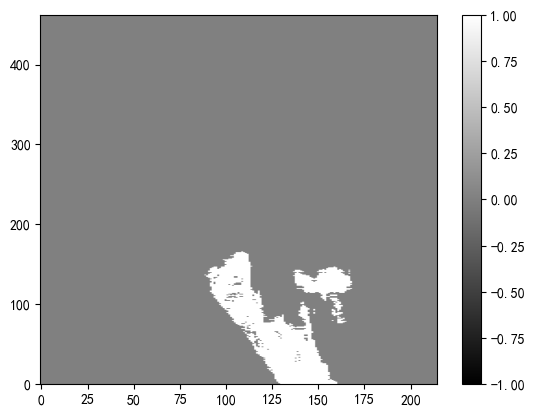

In [ ]:
RVI_dense_cluster_matrix = np.zeros_like(RVI_Filtered)

# 然后遍历most_dense_cluster中的坐标，将这些位置设为1
for (x, y) in most_dense_cluster:
    RVI_dense_cluster_matrix[x, y] = 1
    
plt.imshow(RVI_dense_cluster_matrix, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

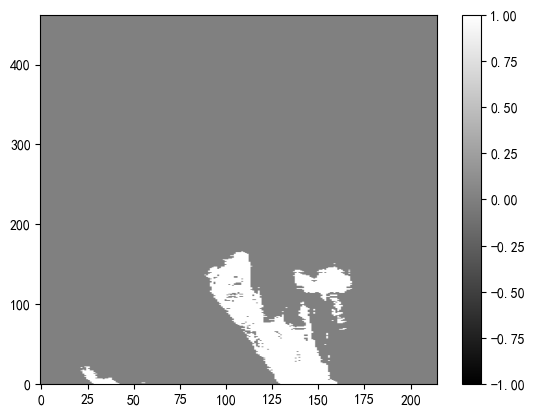

In [ ]:
RVI_dense_cluster_matrix_KM = np.zeros_like(RVI_Filtered)

# 然后遍历most_dense_cluster中的坐标，将这些位置设为1
for (x, y) in most_dense_cluster_KM:
    RVI_dense_cluster_matrix_KM[x, y] = 1
    
plt.imshow(RVI_dense_cluster_matrix_KM, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

聚类效果良好，采用蒙特卡洛方法统计覆盖面积，因为所有遥感分辨率一致，所以方法可行

In [ ]:
# 获取矩阵的维度
rows, cols = RVI_dense_cluster_matrix.shape

# 总样本空间的大小
total_elements = rows * cols

# 抽样次数
num_samples = 100000  # 你可以根据需要调整这个数值

# 随机抽样
count_ones = 0
for _ in range(num_samples):
    # 随机选择行和列
    row = np.random.randint(rows)
    col = np.random.randint(cols)
    
    # 检查该位置是否为1
    if RVI_dense_cluster_matrix[row, col] == 1:
        count_ones += 1

# 计算图形区域占比
area_ratio = count_ones / num_samples

print(f"浒苔占整个地区覆盖的比例约为：{area_ratio}")

浒苔占整个地区覆盖的比例约为：0.05177


还原浒苔真实覆盖面积

In [ ]:
# 31.456万平方公里为地区围成的总面积
Coverage_Area = area_ratio * 31.456
print(f"浒苔的覆盖面积为：{Coverage_Area} 万平方公里")

浒苔的覆盖面积为：1.62847712 万平方公里


计算浒苔聚类中心区域

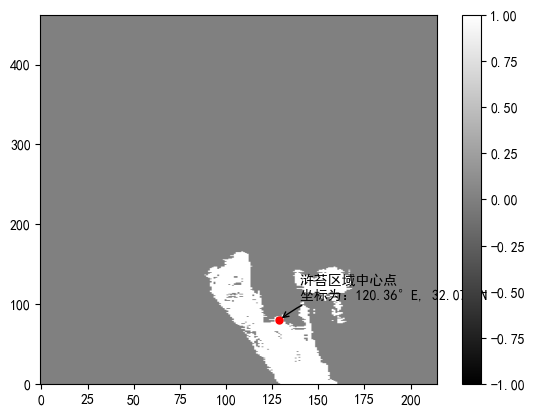

浒苔中心点，坐标为：120.36°E, 32.07°N


In [ ]:
# 计算质心
rows, cols = np.where(RVI_dense_cluster_matrix == 1)
centroid_x = np.mean(cols)
centroid_y = np.mean(rows)

# 计算质心经纬度位置
latitude_start = 31.5
longitude_start = 118.9667
latitude_end = 36.1667
longitude_end = 125.5333

# 计算每个单元格代表的经纬度增量
latitude_increment = (latitude_end - latitude_start) / 654
longitude_increment = (longitude_end - longitude_start) / 609

# 之前计算的质心的坐标，这里用假设数据
centroid_row, centroid_col = (int(round(centroid_y)), int(round(centroid_x)))

# 计算质心的地理坐标
centroid_latitude = latitude_start + (centroid_row * latitude_increment)
centroid_longitude = longitude_start + (centroid_col * longitude_increment)

# 可视化质心和浒苔区域
plt.imshow(RVI_dense_cluster_matrix, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

# 标记中心点
plt.scatter(centroid_col, centroid_row, c='red', s=100, marker='.')

# 注释中心点
plt.annotate(f'浒苔区域中心点 \n坐标为：{centroid_longitude:.2f}°E, {centroid_latitude:.2f}°N',
             xy=(centroid_col, centroid_row), xycoords='data',
             xytext=(15, 15), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

# 显示图像
plt.show()

# 打印中心点的地理坐标
print(f"浒苔中心点，坐标为：{centroid_longitude:.2f}°E, {centroid_latitude:.2f}°N")

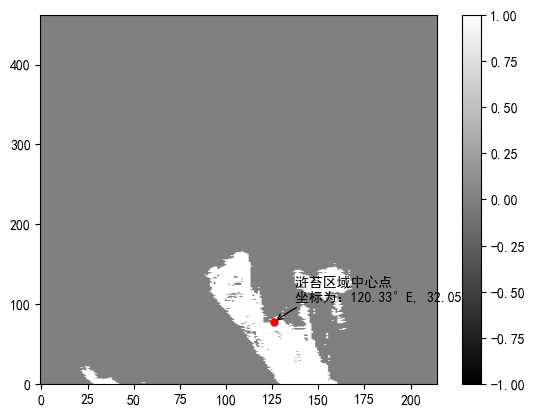

浒苔中心点，坐标为：120.33°E, 32.05°N


In [ ]:
# 计算质心
rows, cols = np.where(RVI_dense_cluster_matrix_KM == 1)
centroid_x = np.mean(cols)
centroid_y = np.mean(rows)

# 计算质心经纬度位置
latitude_start = 31.5
longitude_start = 118.9667
latitude_end = 36.1667
longitude_end = 125.5333

# 计算每个单元格代表的经纬度增量
latitude_increment = (latitude_end - latitude_start) / 654
longitude_increment = (longitude_end - longitude_start) / 609

# 之前计算的质心的坐标，这里用假设数据
centroid_row, centroid_col = (int(round(centroid_y)), int(round(centroid_x)))

# 计算质心的地理坐标
centroid_latitude = latitude_start + (centroid_row * latitude_increment)
centroid_longitude = longitude_start + (centroid_col * longitude_increment)

# 可视化质心和浒苔区域
plt.imshow(RVI_dense_cluster_matrix_KM, origin='lower', aspect='auto', cmap='gray', vmin=-1, vmax=1)
plt.colorbar()

# 标记中心点
plt.scatter(centroid_col, centroid_row, c='red', s=100, marker='.')

# 注释中心点
plt.annotate(f'浒苔区域中心点 \n坐标为：{centroid_longitude:.2f}°E, {centroid_latitude:.2f}°N',
             xy=(centroid_col, centroid_row), xycoords='data',
             xytext=(15, 15), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

# 显示图像
plt.show()

# 打印中心点的地理坐标
print(f"浒苔中心点，坐标为：{centroid_longitude:.2f}°E, {centroid_latitude:.2f}°N")

计算浒苔区域的灰度值总和，作为衡量地区浒苔总量的值

In [ ]:
Volumn = np.sum(RVI_Gray)
print(f"地区浒苔灰度值总和为：{Volumn}")

地区浒苔灰度值总和为：61738.70320284723


In [ ]:
# 打印遥感图像中提取到的所有参数
df = pd.DataFrame({
    '浒苔覆盖面积': Coverage_Area,
    '浒苔质心坐标': [f"{centroid_longitude:.2f}°E, {centroid_latitude:.2f}°N"],
    '浒苔总量': Volumn
})
pd.set_option('display.unicode.east_asian_width', True)
print('遥感数据提取结果：\n', df)

遥感数据提取结果：
    浒苔覆盖面积       浒苔质心坐标      浒苔总量
0      1.628477  120.36°E, 32.07°N  61738.703203
